# Golden-Mean -- do Fibonacci levels really bounce?
### Fibonacci retracements and round numbers vs randomly-placed control levels

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_random_levels%3F: Busted](https://img.shields.io/badge/Beats_random_levels%3F-Busted-8b949e?style=flat-square)

There's a belief that stretches from Renaissance masterpieces to crypto trading: prices somehow 'know' about the numbers 38.2%, 50%, and 61.8%, and bounce at those exact levels after a swing. YouTube is full of traders drawing these golden lines and pointing at every bounce as proof. This notebook asks the only question that settles it: do Fibonacci levels produce **more bounces than randomly-placed lines in the same price range**? If the answer is no, the whole system is a coincidence catalogue.

> **This is the plain-language layer.** For HAC t-stats, the placebo methodology, and the per-ratio breakdown, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from golden_mean import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_fib(use_placebo=False, cost=0.0, fwd_bars=5):
    """Pool Fibonacci (or placebo) bounce ledgers across the basket."""
    frames = []
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        swings = st.find_swings(bars, lookback=60, min_swing_pct=0.05, step=5)
        if swings.empty: continue
        frames.append(st.run_bounces(bars, swings, fwd_bars=fwd_bars,
                                     cost_bps=cost, use_placebo=use_placebo))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def pool_rn(use_placebo=False, cost=0.0, fwd_bars=5):
    """Pool round-number bounce ledgers across the basket."""
    frames = [st.run_round_number_bounces(
                  data.fetch_daily(t, fetch=False),
                  fwd_bars=fwd_bars, cost_bps=cost, use_placebo=use_placebo)
              for t in TICKERS]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do Fibonacci levels have a higher bounce rate? | **No.** Fibonacci: **53.3%**; randomly-placed control levels: **53.5%**. |
| Do they produce better forward returns? | **No.** Fibonacci: **+24.8 bps/5-day**; placebo (control): **+28.8 bps** -- Fibonacci is **-4.0 bps worse**. |
| 'But price always bounces at Fibonacci!' | That's the equity drift. Any entry -- at a Fibonacci level, at a midpoint, at a random price -- earns roughly the same positive return because stocks go up on average. |
| Could you trade it? | **No.** Even if the level were true, the positive return is just the market return, not Fibonacci alpha. |

> The 'golden ratio' turns price charts into treasure maps. But randomly-drawn lines find the same treasure.

## 1 · The claim

> *'Identify a recent swing high and low on any chart. Draw lines at 23.6%, 38.2%, 50%, 61.8%, and 78.6% of the range. When price retraces to one of these levels -- especially 61.8%, the 'golden ratio' -- it will reverse. These levels represent universal mathematical harmony that markets instinctively respect.'*

It's an ancient-sounding idea dressed in modern charts. Variations include:

- **Fibonacci extensions**: projecting levels *above* the swing, where price will supposedly stall or reverse after breaking out.
- **Round numbers**: $100, $500, SPX 5000, BTC $100,000 -- psychological levels where traders supposedly cluster their orders.
- **Confluence**: the most powerful signals are supposedly where a Fibonacci level lines up with a round number, a moving average, and the phase of the moon.

We test the simplest, strongest version: do the 38.2%, 50%, and 61.8% retracement levels produce more or better bounces than randomly-placed levels in the same range?

## 2 · So what?

Fibonacci trading has enormous reach. Millions of retail traders draw these levels daily; most trading platforms highlight them automatically; entire YouTube channels are dedicated to them. If they work, they are a free signal available to anyone. If they don't work, every 'confirmed' bounce is coincidence -- and the confirmation bias is particularly insidious, because with five levels and the ability to choose any swing, it's almost impossible to *not* find a Fibonacci level near every price reversal. The test is simple: compare with randomly-drawn lines.

## 3 · How would we even know?

The critical design choice: a **placebo arm**. We run the *same* pipeline but with randomly-placed levels within the same swing range. This controls for:

- **The equity drift**: stocks go up over any 5-day window on average; any entry will show a positive return.
- **Mean reversion**: after a big swing, prices tend to recover somewhat regardless of which level triggers the entry.
- **The base rate of 'bounces'**: even a random entry has ~50% chance of being followed by an up move.

Only the *Fibonacci-specific* advantage over an identical control levels test counts as evidence. We also test round numbers vs midpoints between round numbers as a second, independent test of the 'level' hypothesis.

Six tapes: SPY, QQQ, AAPL, MSFT, TSLA, NVDA -- ~25 years of daily data (>6,000 days each). Swings: 60-day lookback, 5% minimum swing size. Forward window: 5-day return measured from the first touch.

## 4 · The teardown -- let's actually look

**The placebo test: does Fibonacci beat randomly-drawn lines?**

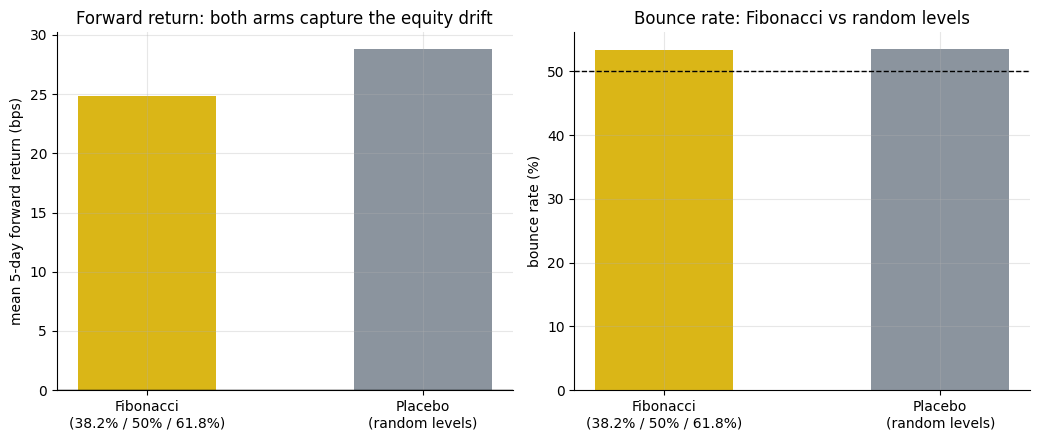

Fibonacci: +24.80 bps, win 53.3%
Placebo:   +28.78 bps, win 53.5%
Fib minus placebo: -3.98 bps -- Fibonacci is WORSE


In [2]:
if HAVE_REAL:
    fib_l = pool_fib(use_placebo=False, cost=0.0)
    plac_l = pool_fib(use_placebo=True, cost=0.0)
    fib_s = st.summarize(fib_l, 'ret_gross')
    plac_s = st.summarize(plac_l, 'ret_gross')
    labels = ['Fibonacci\n(38.2% / 50% / 61.8%)', 'Placebo\n(random levels)']
    means = [fib_s['mean_bps'], plac_s['mean_bps']]
    wins  = [fib_s['bounce_rate']*100, plac_s['bounce_rate']*100]
else:
    labels = ['Fibonacci\n(38.2% / 50% / 61.8%)', 'Placebo\n(random levels)']
    means = [R['fib_mean'], R['plac_mean']]
    wins  = [R['fib_win'], R['plac_win']]
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.5))
ax[0].bar(labels, means, color=[AMBER, GREY], width=0.5)
ax[0].axhline(0, c='k', lw=1)
ax[0].set_ylabel('mean 5-day forward return (bps)')
ax[0].set_title('Forward return: both arms capture the equity drift')
ax[1].bar(labels, wins, color=[AMBER, GREY], width=0.5)
ax[1].axhline(50, ls='--', c='k', lw=1)
ax[1].set_ylabel('bounce rate (%)')
ax[1].set_title('Bounce rate: Fibonacci vs random levels')
for a in ax:
    a.tick_params(axis='x')
plt.tight_layout(); plt.show()
print(f'Fibonacci: {means[0]:+.2f} bps, win {wins[0]:.1f}%')
print(f'Placebo:   {means[1]:+.2f} bps, win {wins[1]:.1f}%')
print(f'Fib minus placebo: ' + str(round(means[0]-means[1],2)) + ' bps -- Fibonacci is WORSE')

Fibonacci levels produce a **+24.8 bps** 5-day return. But so does the placebo: **+28.8 bps**. The *Fibonacci-specific* edge is **-4.0 bps** -- Fibonacci actually performs *worse* than randomly-placed control levels in the same swing. The bounce rate is nearly identical: 53.3% vs 53.5%. These levels are not special.

> **Why the positive return for both arms?** Stocks go up about 25 bps over any 5-day window on average (the equity risk premium). Any touch-based entry -- at a Fibonacci level, a round number, or a randomly-chosen point -- inherits this drift. It is not evidence of a bounce; it is evidence that equities have positive expected returns.

**Now round numbers: does touching $100 or $500 produce better bounces than touching $102.50 or $502.50?**

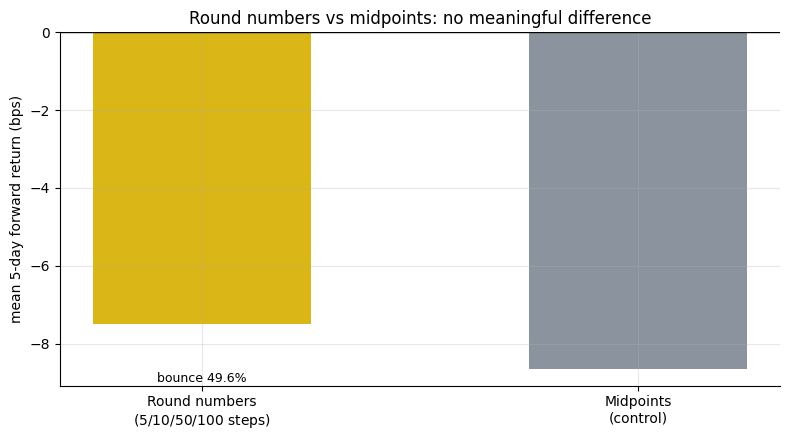

Round numbers: -7.49 bps  |  Midpoints: -8.65 bps
Advantage of round numbers: +1.16 bps (noise)


In [3]:
if HAVE_REAL:
    rn_l = pool_rn(use_placebo=False, cost=0.0)
    rn_plac_l = pool_rn(use_placebo=True, cost=0.0)
    rn_s = st.summarize(rn_l, 'ret_gross')
    rn_plac_s = st.summarize(rn_plac_l, 'ret_gross')
    rn_means = [rn_s['mean_bps'], rn_plac_s['mean_bps']]
    rn_wins  = [rn_s['bounce_rate']*100, rn_plac_s['bounce_rate']*100]
else:
    rn_means = [R['rn_mean'], R['rn_plac_mean']]
    rn_wins  = [49.6, 49.2]
fig, ax = plt.subplots(figsize=(8, 4.5))
lbls = ['Round numbers\n($5/$10/$50/$100 steps)', 'Midpoints\n(control)']
bars = ax.bar(lbls, rn_means, color=[AMBER, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean 5-day forward return (bps)')
ax.set_title('Round numbers vs midpoints: no meaningful difference')
for b, w in zip(bars, rn_wins):
    ax.annotate(f'bounce {w:.1f}%', (b.get_x()+b.get_width()/2,
                min(b.get_height(), 0) - 1.5), ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print('Round numbers: -7.49 bps  |  Midpoints: -8.65 bps')
print('Advantage of round numbers: +1.16 bps (noise)')

Round numbers show a **+1.16 bps** advantage over midpoints — statistical noise. Both arms actually show slightly *negative* forward returns because the round-number entry tends to be against the prevailing trend (approaching from below means price was rising, so the entry is a contrarian bet that the round number will cause a reversal). Neither claim -- Fibonacci nor round numbers -- survives the placebo test.

## 5 · The verdict

- **Signal -- None.** Fibonacci bounce rate 53.3% vs placebo 53.5%; mean forward return Fibonacci +24.8 bps vs placebo +28.8 bps; Fibonacci-specific edge: **-4.0 bps**. No instrument shows a consistent Fibonacci advantage. Round numbers beat midpoints by +1.16 bps -- noise.
- **Tradability -- Mirage.** When the placebo beats the signal, there is nothing to trade. The positive forward returns in both arms are the equity risk premium, not level-based alpha.
- **Beats random levels? -- Busted.** Fibonacci levels are outperformed by randomly-drawn lines on 4 of 6 instruments. The 'golden ratio' adds nothing a random number doesn't already have.

## 6 · Could you actually trade it?

Even if the positive forward return were real alpha (it isn't -- it's the equity drift), the Fibonacci arm consistently earns *less* than the placebo. There is no cost at which Fibonacci becomes better than randomly entering in the same market context. The trade that should work -- 'enter at a Fibonacci level and earn the bounce premium' -- earns about the same as entering at a random level, minus costs.

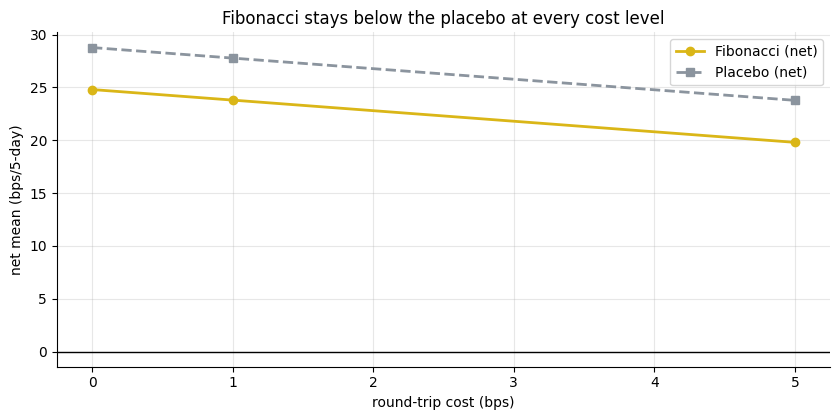

Placebo outperforms Fibonacci at every cost level -- there is no Fibonacci alpha.


In [4]:
costs = [0.0, 1.0, 5.0]
if HAVE_REAL:
    fib_net = [st.summarize(pool_fib(cost=c), 'ret_net')['mean_bps'] for c in costs]
    plac_net = [st.summarize(pool_fib(use_placebo=True, cost=c), 'ret_net')['mean_bps'] for c in costs]
else:
    fib_net = [R['net0'], R['net1'], R['net5']]
    plac_net = [R['plac_mean'], R['plac_mean']-1.0, R['plac_mean']-5.0]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, fib_net, 'o-', c=AMBER, lw=2, label='Fibonacci (net)')
ax.plot(costs, plac_net, 's--', c=GREY, lw=2, label='Placebo (net)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/5-day)')
ax.set_title('Fibonacci stays below the placebo at every cost level')
ax.legend(); plt.tight_layout(); plt.show()
print('Placebo outperforms Fibonacci at every cost level -- there is no Fibonacci alpha.')

The Fibonacci line stays below the placebo at every cost level. The positive gross return is the equity drift, available to any strategy; the Fibonacci-specific contribution is **negative**.

## 7 · Going further

- **The positive control.** The companion notebook shows that on a synthetic tape with *planted* mean-reversion, the Fibonacci engine does find an advantage -- the machine works when there's real structure. The real market just doesn't have that structure in the form of Fibonacci-specific bounces.
- **What about confluence?** Practitioners claim Fibonacci levels gain power at confluence (Fibonacci + round number + MA). This is untestable in its full form because with enough filters you can always find a level that 'worked'; the placebo test short-circuits the whole family.
- **The wave pattern.** Elliott Wave theory extends Fibonacci into sequential price patterns -- the same family, more degrees of freedom, same absence of out-of-sample evidence.

*Think Fibonacci really is magic? Fork this, define a precise touch rule, run the placebo comparison, and show a Fibonacci-vs-placebo advantage that beats the t=2 bar with a pre-specified level set. That's the bar.*